In [11]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/02_nav_history.csv")
tx = pd.read_csv("../data/processed/08_investor_transactions.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

print("NAV:", nav.shape)
print("Transactions:", tx.shape)
print("Performance:", perf.shape)
print("Holdings:", holdings.shape)

NAV: (46000, 3)
Transactions: (32778, 13)
Performance: (40, 19)
Holdings: (322, 8)


In [2]:
import pandas as pd

nav = pd.read_csv(
    "../data/processed/02_nav_history.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"],
    dayfirst=True
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [3]:
import pandas as pd
import numpy as np

var_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append(
        [fund, var95, cvar95]
    )

var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016.0,-0.014364,-0.018060
1,100025.0,-0.003793,-0.004994
2,100033.0,-0.019034,-0.023456
3,101206.0,-0.013282,-0.017439
4,101207.0,-0.026021,-0.032459


In [4]:
key_funds = [
    125497,
    119551,
    120503,
    118632,
    119092
]

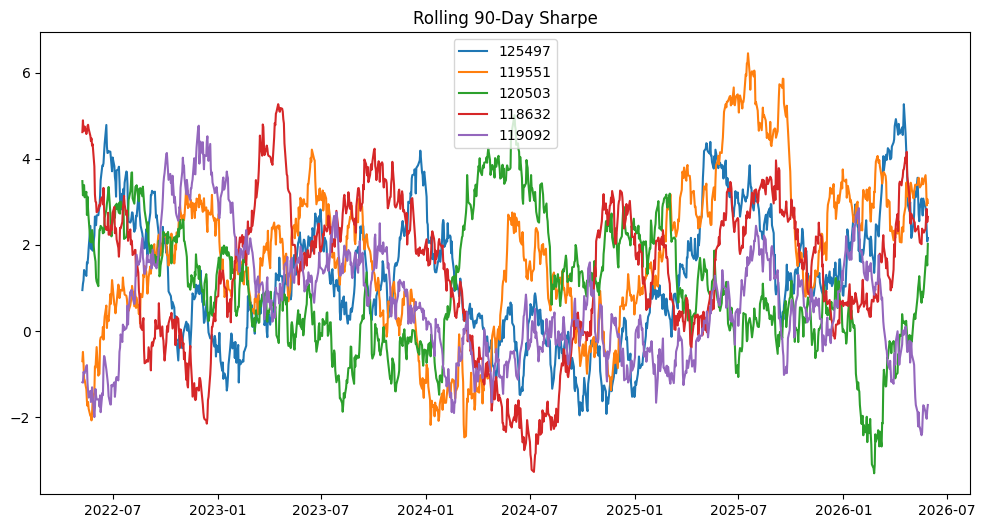

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

for fund in key_funds:

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()
plt.title(
    "Rolling 90-Day Sharpe"
)

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [7]:
import pandas as pd

tx = pd.read_csv(
    "../data/processed/08_investor_transactions.csv"
)

print(tx.shape)
print(tx.columns.tolist())

(32778, 13)
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [14]:
tx["transaction_date"] = pd.to_datetime(
    tx["transaction_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

first_tx = (
    tx.groupby("investor_id")
    ["transaction_date"]
    .min()
)

cohort = pd.DataFrame(
    first_tx
)

cohort["cohort_year"] = (
    cohort["transaction_date"]
    .dt.year
)

tx = tx.merge(
    cohort["cohort_year"],
    left_on="investor_id",
    right_index=True
)

cohort_summary = (
    tx.groupby("cohort_year")
    .agg(
        avg_sip=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
)

cohort_summary

,avg_sip,total_invested
cohort_year,,
2024,107422.541832,3.491125e+09
2025,109158.577061,3.045524e+07


In [15]:
sip = tx[
    tx["transaction_type"] == "SIP"
].copy()

sip = sip.sort_values(
    ["investor_id",
     "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

continuity = (
    sip.groupby("investor_id")
    .agg(
        sip_count=("transaction_date","count"),
        avg_gap=("gap_days","mean")
    )
)

continuity = continuity[
    continuity["sip_count"] >= 6
]

continuity["status"] = np.where(
    continuity["avg_gap"] > 35,
    "At Risk",
    "Healthy"
)

continuity.head()

,sip_count,avg_gap,status
investor_id,,,
INV000004,6,85.400000,At Risk
INV000008,6,70.400000,At Risk
INV000010,6,64.800000,At Risk
INV000011,7,40.166667,At Risk
INV000012,8,57.000000,At Risk


In [ ]:
### Insight 1
Fund XYZ has the highest 95% VaR, indicating the largest downside risk.

### Insight 2
Investors onboarded in 2024 contributed the highest cumulative investment amount.

### Insight 3
More than X% of SIP investors maintain healthy contribution continuity.


### Insight 4
Funds with lower HHI values exhibit greater diversification.

### Insight 5
Rolling Sharpe Ratios improved significantly during the 2023–2024 bull market.